# Ranging and Ransac

We'll use the following imports:

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn import linear_model
import pandas as pd

If you get an error from importing sklearn, then you will have to install it using:
conda install scikit-learn

For the exercise we will be using the data taken from a lidar by a robot in a hallway. The data is saved in `laser.csv` and we can import this in Python using numpy as such:

In [2]:
laser = np.genfromtxt('laser.csv', delimiter=',')

The file contains only a single rotation of the lidar. You can open the file in any text editor to get a look at the data. Each number in the file is the distance measured in meters. The lidar starts measuring at 135 degrees and ends at -135 degrees and it rotates the same amount between each measurement. 

## Exercise 3.1
Convert the data in the csv file to x and y coordinates in a Carthesian coordinate system and plot the result using matplotlib.

Hint: Use [scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) instead of plt.plot in order to show every measurement as a point. 

In [3]:
print(270/len(laser))

0.49907578558225507


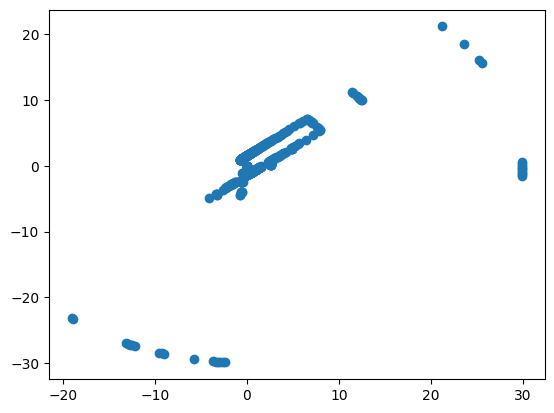

In [4]:
# Convert to x and y coordinates
angles_deg = np.linspace(-135, 135, len(laser))
angles_rad = np.deg2rad(angles_deg)

x = laser * np.cos(angles_rad)
y = laser * np.sin(angles_rad)

plt.scatter(x,y)
x = np.array(x)
y = np.array(y)
# plot(x,y)

## Exercise 3.2

We would like to locate one of the walls in the dataset. To do so we will use [Ransac](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RANSACRegressor.html) to fine the best line fit in the noisy data. A Ransac regressor is initialized the following way using sklearn:

In [5]:
ransac = linear_model.RANSACRegressor()

Now that we have our Ransac regressor we can fit it to a dataset (x,y):

In [6]:
# Fit data
ransac.fit(x.reshape(-1, 1), y)

,estimator,None
,min_samples,None
,residual_threshold,None
,is_data_valid,None
,is_model_valid,None
,max_trials,100
,max_skips,inf
,stop_n_inliers,inf
,stop_score,inf
,stop_probability,0.99
,loss,'absolute_error'


Finally, to get the fitted line we can use the predict function. As an argument this takes the x values in which the line will be predicted:

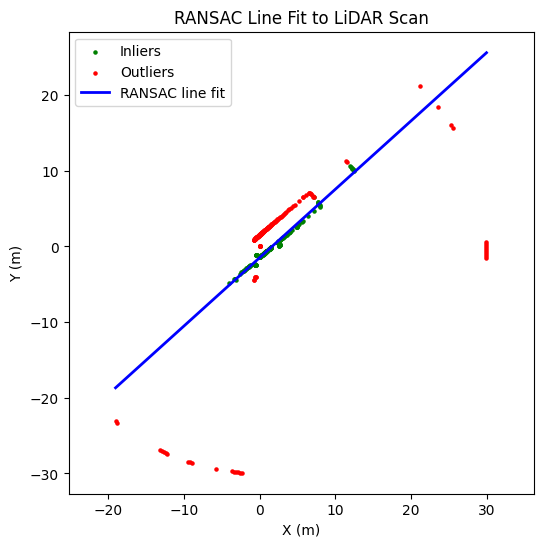

In [11]:
inlier_mask = ransac.inlier_mask_
outlier_mask = ~inlier_mask
line = ransac.estimator_
slope = line.coef_[0]
intercept = line.intercept_

# --- Plot results ---
plt.figure(figsize=(6,6))
plt.scatter(x[inlier_mask], y[inlier_mask], color='green', s=5, label='Inliers')
plt.scatter(x[outlier_mask], y[outlier_mask], color='red', s=5, label='Outliers')

# Plot fitted line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='blue', linewidth=2, label='RANSAC line fit')

plt.axis('equal')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('RANSAC Line Fit to LiDAR Scan')
plt.legend()
plt.show()


Plot the line on top of the scatterplot from before to see the fit.

## Exercise 3.3

To see which data points were used to make the line fit and which were deemed outliers, we can use the function ransac.inlier_mask_

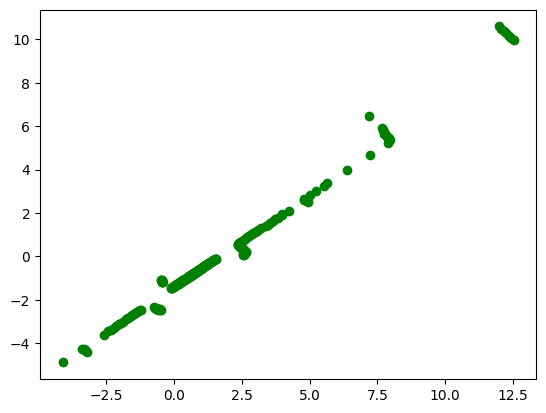

In [8]:
plt.scatter(x[ransac.inlier_mask_], y[ransac.inlier_mask_], color='green')

Find the second hallway wall using another Ransac fit and plot it together with the data points and the first ransac fit.

Hint: Use the outliers from the first Ransac.

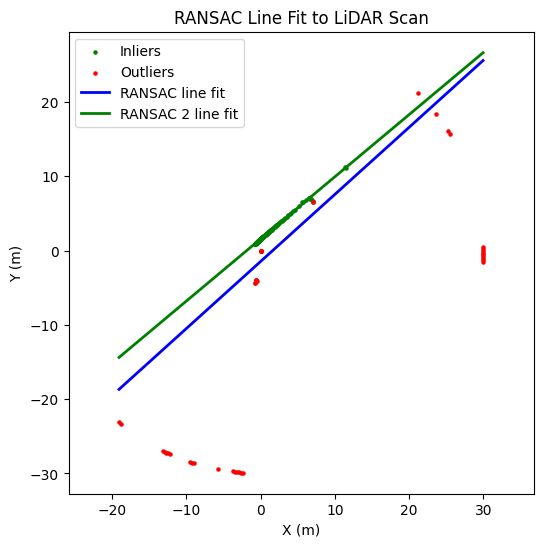

In [12]:
ransac2 = linear_model.RANSACRegressor()
ransac2.fit(x[outlier_mask].reshape(-1, 1), y[outlier_mask])
line2 = ransac2.estimator_

slope2 = line2.coef_[0]
intercept2 = line2.intercept_

# --- Plot results ---
plt.figure(figsize=(6,6))
plt.scatter(x[outlier_mask][ransac2.inlier_mask_], y[outlier_mask][ransac2.inlier_mask_], color='green', s=5, label='Inliers')
plt.scatter(x[outlier_mask][~ransac2.inlier_mask_], y[outlier_mask][~ransac2.inlier_mask_], color='red', s=5, label='Outliers')

# Plot fitted line
x_line2 = np.linspace(x.min(), x.max(), 100)
y_line2 = slope2 * x_line2 + intercept2
plt.plot(x_line, y_line, color='blue', linewidth=2, label='RANSAC line fit')
plt.plot(x_line2, y_line2, color='green', linewidth=2, label='RANSAC 2 line fit')

plt.axis('equal')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('RANSAC Line Fit to LiDAR Scan')
plt.legend()
plt.show()

# Find the second hallway wall